In [1]:
import pandas as pd
import os

op_settings = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensors = [f'sensor_{i}' for i in range(1, 22)]
cols = ['unit_number', 'time_in_cycles'] + op_settings + sensors

data_path = 'data/'

train_data = {}
test_data = {}
rul_data = {}

datasets_to_load = ['FD001', 'FD002', 'FD003', 'FD004']

print("Loading datasets...")

for ds_name in datasets_to_load:
    train_file = os.path.join(data_path, f'train_{ds_name}.txt')
    train_df = pd.read_csv(train_file, sep=' ', header=None, names=cols, index_col=False)
    train_df.drop(columns=[26, 27], inplace=True, errors='ignore')
    train_data[ds_name] = train_df

    test_file = os.path.join(data_path, f'test_{ds_name}.txt')
    test_df = pd.read_csv(test_file, sep=' ', header=None, names=cols, index_col=False)
    test_df.drop(columns=[26, 27], inplace=True, errors='ignore')
    test_data[ds_name] = test_df

    rul_file = os.path.join(data_path, f'RUL_{ds_name}.txt')
    rul_df = pd.read_csv(rul_file, header=None, names=['RUL'], index_col=False)
    rul_data[ds_name] = rul_df

print("All datasets loaded successfully.")

print("\n--- Example: Head of train_FD001 ---")
print(train_data['FD001'].head())

print("\n--- Example: Head of test_FD001 ---")
print(test_data['FD001'].head())

print("\n--- Example: Head of RUL_FD001 ---")
print(rul_data['FD001'].head())

Loading datasets...


C:\Users\abhin\AppData\Local\Temp\ipykernel_14876\1612479227.py:20: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv(train_file, sep=' ', header=None, names=cols, index_col=False)
C:\Users\abhin\AppData\Local\Temp\ipykernel_14876\1612479227.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  test_df = pd.read_csv(test_file, sep=' ', header=None, names=cols, index_col=False)
C:\Users\abhin\AppData\Local\Temp\ipykernel_14876\1612479227.py:20: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv(train_file, sep=' ', header=None, names=cols, index_col=False)
C:\Users\abhin\AppData\Local\Temp\ipykernel_14876\1612479227.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of d

All datasets loaded successfully.

--- Example: Head of train_FD001 ---
   unit_number  time_in_cycles  op_setting_1  op_setting_2  op_setting_3  \
0            1               1       -0.0007       -0.0004         100.0   
1            1               2        0.0019       -0.0003         100.0   
2            1               3       -0.0043        0.0003         100.0   
3            1               4        0.0007        0.0000         100.0   
4            1               5       -0.0019       -0.0002         100.0   

   sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  \
0    518.67    641.82   1589.70   1400.60     14.62  ...     521.66   
1    518.67    642.15   1591.82   1403.14     14.62  ...     522.28   
2    518.67    642.35   1587.99   1404.20     14.62  ...     522.42   
3    518.67    642.35   1582.79   1401.87     14.62  ...     522.86   
4    518.67    642.37   1582.85   1406.22     14.62  ...     522.19   

   sensor_13  sensor_14  sensor_15  sensor_1

C:\Users\abhin\AppData\Local\Temp\ipykernel_14876\1612479227.py:20: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv(train_file, sep=' ', header=None, names=cols, index_col=False)
C:\Users\abhin\AppData\Local\Temp\ipykernel_14876\1612479227.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  test_df = pd.read_csv(test_file, sep=' ', header=None, names=cols, index_col=False)


Load the training data into a Pandas DataFrame. The columns are not named, so you'll need to assign them names like 'engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', ..., 'sensor_21'.

In [2]:
import pandas as pd
import os

column_names = [
    'engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
    'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'
]

data_path = 'data/'
all_train_dfs = {}

print("Loading training data...")

for i in range(1, 5):
    filename = f'train_FD00{i}.txt'
    file_path = os.path.join(data_path, filename)
    
    try:
        df = pd.read_csv(file_path, sep='\\s+', header=None, names=column_names)
        all_train_dfs[f'FD00{i}'] = df
        print(f"Loaded {file_path} successfully.")
    except FileNotFoundError:
        print(f"ERROR: {file_path} not found. Please make sure it's in the '{data_path}' folder.")
    except Exception as e:
        print(f"An error occurred while loading {file_path}: {e}")

if all_train_dfs:
    print("\nLoading complete. You can access each dataframe like: all_train_dfs['FD001']")
    
    if 'FD004' in all_train_dfs:
        print("\nDisplaying the first 5 rows of the FD004 training data:")
        display(all_train_dfs['FD004'].head())
    else:
        print("\nFD004 data was not loaded.")

Loading training data...
Loaded data/train_FD001.txt successfully.
Loaded data/train_FD002.txt successfully.
Loaded data/train_FD003.txt successfully.
Loaded data/train_FD004.txt successfully.

Loading complete. You can access each dataframe like: all_train_dfs['FD001']

Displaying the first 5 rows of the FD004 training data:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


Plot the sensor readings over time (cycles) for a few different engines. This will help you visually confirm how sensor values trend as an engine approaches failure

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

def create_degradation_plots(df, dataset_name, sensors, num_engines_to_plot=5):
    print(f"\n---  Generating plots for dataset: {dataset_name} ---")

    plt.style.use('dark_background')
    subset_df = df[df['engine_id'] <= num_engines_to_plot]

    fig, axes = plt.subplots(nrows=len(sensors), ncols=1, figsize=(14, 20), sharex=True)
    fig.suptitle(f'Sensor Degradation Trends for {dataset_name} (First {num_engines_to_plot} Engines)', fontsize=18)

    palette = sns.color_palette("viridis", n_colors=num_engines_to_plot)

    for i, sensor in enumerate(sensors):
        sns.lineplot(data=subset_df, x='cycle', y=sensor, hue='engine_id', ax=axes[i], palette=palette, legend=False)
        axes[i].set_ylabel(sensor)
        axes[i].grid(True, linestyle=':', alpha=0.5)
        axes[i].set_title(f'Trend for {sensor}', loc='right', fontsize=10)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Engine ID', bbox_to_anchor=(1.0, 0.9), loc='upper left')

    axes[-1].set_xlabel('Operational Cycle')
    plt.tight_layout(rect=[0, 0, 0.9, 0.98])
    
    plot_filename = f'{dataset_name}_degradation_plots.png'
    plt.savefig(plot_filename)
    print(f"Saved plot to {plot_filename}")
    plt.close(fig)

try:
    sensors_to_plot = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15']

    if 'all_train_dfs' not in locals():
        print("Error: The 'all_train_dfs' dictionary is not defined. Please run the previous cell to load the data first.")
    else:
        for name, df in all_train_dfs.items():
            create_degradation_plots(df, name, sensors_to_plot)

except NameError:
    print("Error: A NameError occurred. Make sure 'all_train_dfs' is defined and all libraries are imported.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


---  Generating plots for dataset: FD001 ---
Saved plot to FD001_degradation_plots.png

---  Generating plots for dataset: FD002 ---
Saved plot to FD002_degradation_plots.png

---  Generating plots for dataset: FD003 ---
Saved plot to FD003_degradation_plots.png

---  Generating plots for dataset: FD004 ---
Saved plot to FD004_degradation_plots.png


The dataset doesn't provide an RUL column for the training set. You must create it yourself. For each engine, find its maximum cycle number. The RUL for any given cycle is the maximum cycle minus the current cycle number. This will be your target variable for the regression task.

In [4]:
import pandas as pd

try:
    if 'all_train_dfs' not in locals() or not all_train_dfs:
        print("Error: 'all_train_dfs' not found or is empty. Please run the cell to load the dataframes first.")
    else:
        for name, df in all_train_dfs.items():
            max_cycles = df.groupby('engine_id')['cycle'].transform('max')
            df['RUL'] = max_cycles - df['cycle']
            print(f"Calculated RUL for dataset: {name}")

        print("\nCalculation complete. Each DataFrame now has an 'RUL' column.")
        
        if 'FD001' in all_train_dfs:
            print("\nDisplaying the last 5 rows for Engine 1 in FD001 to verify:")
            display(all_train_dfs['FD001'][all_train_dfs['FD001']['engine_id'] == 1].tail())

except NameError:
    print("Error: A NameError occurred. Make sure 'all_train_dfs' is defined.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Calculated RUL for dataset: FD001
Calculated RUL for dataset: FD002
Calculated RUL for dataset: FD003
Calculated RUL for dataset: FD004

Calculation complete. Each DataFrame now has an 'RUL' column.

Displaying the last 5 rows for Engine 1 in FD001 to verify:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0


Analyze the variance of each sensor column. You will notice that some sensors have zero or near-zero variance, meaning they don't change over time and provide no useful information for predicting degradation. Remove these columns from both your training and testing datasets.

In [5]:
import pandas as pd

try:
    static_cols_map = {}

    print("--- Analyzing and Removing Static Columns ---")

    for name, df in all_train_dfs.items():
        data_std = df.std()
        static_cols = data_std[data_std == 0].index.tolist()

        static_cols_map[name] = static_cols

        if static_cols:
            df.drop(columns=static_cols, inplace=True)
            print(f" For {name}, removed columns: {static_cols}")
        else:
            print(f" No static columns found in {name}.")

    print("\nProcessing complete.")
    print("\nThis map stores the columns removed from each dataset (for later use on test data):")
    print(static_cols_map)

    print(f"\nExample: New number of columns in FD001 is now {all_train_dfs['FD001'].shape[1]}")

except NameError:
    print("Error: 'all_train_dfs' not defined. Please run the cell to load the dataframes first.")

--- Analyzing and Removing Static Columns ---
 For FD001, removed columns: ['op_setting_3', 'sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']
 No static columns found in FD002.
 For FD003, removed columns: ['op_setting_3', 'sensor_1', 'sensor_18', 'sensor_19']
 No static columns found in FD004.

Processing complete.

This map stores the columns removed from each dataset (for later use on test data):
{'FD001': ['op_setting_3', 'sensor_1', 'sensor_10', 'sensor_18', 'sensor_19'], 'FD002': [], 'FD003': ['op_setting_3', 'sensor_1', 'sensor_18', 'sensor_19'], 'FD004': []}

Example: New number of columns in FD001 is now 22


The sensor measurements have different scales and units (e.g., psia, rpm). It's essential to scale them to a common range, like [0, 1] or [-1, 1]. Use a
 MinMaxScaler or StandardScaler from Scikit-learn. Important: Fit the scaler only on the training data, and then use that same fitted scaler to transform both the training and testing data. This prevents data leakage.

In [6]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

try:
    if 'all_train_dfs' not in locals() or not all_train_dfs:
        print("Error: 'all_train_dfs' not found or is empty. Please run the previous cells first.")
    else:
        scalers = {}

        print("--- Fitting Scalers and Normalizing Each Training Dataset ---")

        for name, df in all_train_dfs.items():
            feature_cols = [col for col in df.columns if col not in ['engine_id', 'cycle', 'RUL']]
            
            if not feature_cols:
                print(f" No feature columns found for {name}. Skipping normalization.")
                continue

            scaler = MinMaxScaler()
            df[feature_cols] = scaler.fit_transform(df[feature_cols])

            scalers[name] = scaler
            print(f" Features for {name} normalized. Scaler saved.")

        print("\nNormalization complete for all training datasets.")
        print("The fitted scaler for each dataset is now stored in the 'scalers' dictionary.")

        if 'FD001' in all_train_dfs:
            print("\nVerifying normalization on FD001 data:")
            feature_cols_fd001 = [col for col in all_train_dfs['FD001'].columns if col not in ['engine_id', 'cycle', 'RUL']]
            if feature_cols_fd001:
                display(all_train_dfs['FD001'][feature_cols_fd001].describe().loc[['min', 'max']])
            else:
                print(" FD001 has no feature columns to display.")

except NameError:
    print("Error: 'all_train_dfs' not defined. Please run the previous cells first.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- Fitting Scalers and Normalizing Each Training Dataset ---
 Features for FD001 normalized. Scaler saved.
 Features for FD002 normalized. Scaler saved.
 Features for FD003 normalized. Scaler saved.
 Features for FD004 normalized. Scaler saved.

Normalization complete for all training datasets.
The fitted scaler for each dataset is now stored in the 'scalers' dictionary.

Verifying normalization on FD001 data:


,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0


Your CNN-LNN model needs to be fed sequences of data, not single rows. You'll need to create a "sliding window" function.
Define a window size: Choose a sequence length, for example, 30 cycles.
Slide through each engine's data: For each engine, create sequences. The first sequence would be cycles 1-30, the next would be 2-31, and so on.
Assign Labels: The label for each sequence is the RUL of the last cycle in that window. For the sequence of cycles 1-30, the label would be the RUL at cycle 30.
This will transform your data into a 3D array of shape (number_of_samples, window_size, number_of_features), which is the required input format for your model.

In [7]:
import pandas as pd
import numpy as np

def generate_sequences_for_df(df, window_size):
    feature_cols = [col for col in df.columns if col not in ['engine_id', 'cycle', 'RUL']]
    
    sequences = []
    labels = []

    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]
        
        if len(engine_df) < window_size:
            continue
            
        feature_data = engine_df[feature_cols].values
        label_data = engine_df['RUL'].values

        for i in range(len(engine_df) - window_size + 1):
            sequences.append(feature_data[i:i+window_size])
            labels.append(label_data[i+window_size-1])

    return np.array(sequences), np.array(labels)

try:
    if 'all_train_dfs' not in locals() or not all_train_dfs:
        print("Error: 'all_train_dfs' not defined or is empty. Please run the previous cells first.")
    else:
        WINDOW_SIZE = 30
        all_sequence_data = {}

        print("--- Generating Time-Series Sequences ---")

        for name, df in all_train_dfs.items():
            X, y = generate_sequences_for_df(df, WINDOW_SIZE)
            all_sequence_data[name] = {'X': X, 'y': y}
            print(f" Sequences created for {name}.")

        print("\nProcessing complete. You can access the data like: all_sequence_data['FD001']['X']")

        print("\n--- Summary of Final Data Shapes ---")
        for name, data in all_sequence_data.items():
            if data['X'] is not None and data['y'] is not None:
                print(f"Dataset {name}: X_train shape={data['X'].shape}, y_train shape={data['y'].shape}")
            else:
                print(f"Dataset {name}: No sequences generated (likely due to window size).")

except NameError:
    print("Error: 'all_train_dfs' not defined. Please run the previous cells first.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- Generating Time-Series Sequences ---
 Sequences created for FD001.
 Sequences created for FD002.
 Sequences created for FD003.
 Sequences created for FD004.

Processing complete. You can access the data like: all_sequence_data['FD001']['X']

--- Summary of Final Data Shapes ---
Dataset FD001: X_train shape=(17731, 30, 19), y_train shape=(17731,)
Dataset FD002: X_train shape=(46219, 30, 24), y_train shape=(46219,)
Dataset FD003: X_train shape=(21820, 30, 20), y_train shape=(21820,)
Dataset FD004: X_train shape=(54028, 30, 24), y_train shape=(54028,)


Code to upload and load all train_FD00x.txt files into the all_train_dfs dictionary.

In [8]:
import pandas as pd
import os

column_names = [
    'engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
    'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'
]

data_path = 'data/'
all_train_dfs = {}
print("Loading training data...")

for i in range(1, 5):
    filename = f'train_FD00{i}.txt'
    dataset_key = f'FD00{i}'
    file_path = os.path.join(data_path, filename)

    try:
        df = pd.read_csv(file_path, sep='\\s+', header=None, names=column_names)
        all_train_dfs[dataset_key] = df
        print(f" Loaded {file_path} into all_train_dfs['{dataset_key}']")
    except FileNotFoundError:
        print(f" ERROR: {file_path} not found. Please make sure it's in the '{data_path}' folder.")
    except Exception as e:
        print(f"An error occurred with {file_path}: {e}")

if all_train_dfs:
    print("\n--- Verification ---")
    if 'FD004' in all_train_dfs:
        print("Displaying the first 5 rows of the FD004 training data:")
        display(all_train_dfs['FD004'].head())
    else:
        print("FD004 data was not loaded, cannot display head.")

Loading training data...
 Loaded data/train_FD001.txt into all_train_dfs['FD001']
 Loaded data/train_FD002.txt into all_train_dfs['FD002']
 Loaded data/train_FD003.txt into all_train_dfs['FD003']
 Loaded data/train_FD004.txt into all_train_dfs['FD004']

--- Verification ---
Displaying the first 5 rows of the FD004 training data:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [9]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def calculate_rul(df):
    df_with_rul = df.copy()
    max_cycles = df_with_rul.groupby('engine_id')['cycle'].transform('max')
    df_with_rul['RUL'] = max_cycles - df_with_rul['cycle']
    return df_with_rul

def remove_static_cols(df):
    df_processed = df.copy()
    data_std = df_processed.std()
    static_cols = data_std[data_std == 0].index.tolist()

    if static_cols:
        df_processed.drop(columns=static_cols, inplace=True)

    return df_processed, static_cols

def normalize_features(df):
    df_processed = df.copy()
    feature_cols = [col for col in df_processed.columns if col not in ['engine_id', 'cycle', 'RUL']]

    scaler = MinMaxScaler()
    df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

    return df_processed, scaler


print(" Helper functions are now defined and ready to be used:")
print("- calculate_rul(df)")
print("- remove_static_cols(df)")
print("- normalize_features(df)")

 Helper functions are now defined and ready to be used:
- calculate_rul(df)
- remove_static_cols(df)
- normalize_features(df)


Sequence Generation Function: Define the generate_sequences function.

In [10]:
import pandas as pd
import numpy as np

def generate_sequences(df, window_size):
    feature_cols = [col for col in df.columns if col not in ['engine_id', 'cycle', 'RUL']]

    sequences = []
    labels = []

    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].values
        label_data = engine_df['RUL'].values

        for i in range(len(engine_df) - window_size + 1):
            sequences.append(feature_data[i:i+window_size])
            labels.append(label_data[i+window_size-1])

    return np.array(sequences), np.array(labels)

print(" Helper function 'generate_sequences' is now defined.")
print("It's ready to be used in the final preprocessing step.")

 Helper function 'generate_sequences' is now defined.
It's ready to be used in the final preprocessing step.


Execute Preprocessing Pipeline: The main script that calls the functions above to process the raw data and create the final X_train and y_train sequence arrays.

In [11]:
import pandas as pd
import numpy as np

try:
    processed_dfs = {}
    static_cols_map = {}
    scalers_map = {}
    all_sequence_data = {}

    WINDOW_SIZE = 30

    print("--- 🚀 Executing Preprocessing Pipeline for All Datasets ---")

    for name, df in all_train_dfs.items():
        print(f"\nProcessing {name}...")

        df_rul = calculate_rul(df)

        df_no_static, static_cols = remove_static_cols(df_rul)
        static_cols_map[name] = static_cols

        df_normalized, scaler = normalize_features(df_no_static)
        scalers_map[name] = scaler

        X_train, y_train = generate_sequences(df_normalized, WINDOW_SIZE)
        all_sequence_data[name] = {'X': X_train, 'y': y_train}

        print(f" {name} processing complete.")

    print("\n\n---  Pipeline Finished ---")
    print("Final sequence data is stored in 'all_sequence_data'.")
    print("Artifacts for test set processing are stored in 'static_cols_map' and 'scalers_map'.")

    print("\n--- Summary of Generated Data Shapes ---")
    for name, data in all_sequence_data.items():
        print(f"Dataset {name}: X_train shape={data['X'].shape}, y_train shape={data['y'].shape}")

except NameError as e:
    print(f"Error: A required variable or function is not defined: {e}")
    print("Please ensure 'all_train_dfs' and all helper functions (calculate_rul, remove_static_cols, normalize_features, generate_sequences) are defined first.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- 🚀 Executing Preprocessing Pipeline for All Datasets ---

Processing FD001...
 FD001 processing complete.

Processing FD002...
 FD002 processing complete.

Processing FD003...
 FD003 processing complete.

Processing FD004...
 FD004 processing complete.


---  Pipeline Finished ---
Final sequence data is stored in 'all_sequence_data'.
Artifacts for test set processing are stored in 'static_cols_map' and 'scalers_map'.

--- Summary of Generated Data Shapes ---
Dataset FD001: X_train shape=(17731, 30, 19), y_train shape=(17731,)
Dataset FD002: X_train shape=(46219, 30, 24), y_train shape=(46219,)
Dataset FD003: X_train shape=(21820, 30, 20), y_train shape=(21820,)
Dataset FD004: X_train shape=(54028, 30, 24), y_train shape=(54028,)


In [12]:
pip install liquidnet

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [14]:
import torch
import torch.nn as nn
from liquidnet.main import LiquidNet

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, window_size, cnn_filters=32, lnn_units=128, dense_units=64):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units

        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.5)
        )

        # Determine the output size from the CNN to feed into the LNN
        cnn_output_size = self._get_cnn_output_size(num_features, window_size)

        self.lnn_core = LiquidNet(num_units=lnn_units)

        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(),
            nn.Linear(in_features=dense_units, out_features=1)
        )

    def _get_cnn_output_size(self, num_features, window_size):
        # Helper to calculate the flattened size after CNN layers
        with torch.no_grad():
            dummy_input = torch.zeros(1, num_features, window_size)
            dummy_output = self.cnn_feature_extractor(dummy_input)
            return dummy_output.shape[1] # Returns the number of output channels

    def forward(self, x):
        # Input x shape: (batch_size, window_size, num_features)
        x = x.permute(0, 2, 1)
        # Permuted x shape: (batch_size, num_features, window_size)

        x = self.cnn_feature_extractor(x)

        # CNN output shape: (batch_size, cnn_output_channels, new_window_size)
        x = x.permute(0, 2, 1)
        # Permuted back: (batch_size, new_window_size, cnn_output_channels)

        batch_size = x.size(0)
        seq_len = x.size(1)

        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)

        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)

        # Final hidden_state is the output of the LNN core
        x = self.output_head(hidden_state)

        return x

In [15]:
import torch

try:
    if 'all_sequence_data' not in locals() or 'HybridCnnLnn' not in locals():
        print("Error: Please ensure 'all_sequence_data' and the 'HybridCnnLnn' class are defined.")
    else:
        WINDOW_SIZE = 30
        model_input_params = {}
        all_models = {}

        print("--- Determining Input Parameters and Creating Models ---")

        for name, data in all_sequence_data.items():
            num_features = data['X'].shape[2]
            params = {
                'num_features': num_features,
                'window_size': WINDOW_SIZE
            }
            model_input_params[name] = params

            model = HybridCnnLnn(
                num_features=params['num_features'],
                window_size=params['window_size']
            )
            all_models[name] = model
            print(f" Model for {name} created with input features={num_features}, window_size={WINDOW_SIZE}")

        print("\n--- Verification ---")
        print("A separate model has been created for each dataset and stored in the 'all_models' dictionary.")
        
        if 'FD001' in all_models:
            print("\nExample structure for the FD001 model:")
            print(all_models['FD001'])

except NameError as e:
    print(f"Error: A required variable or function is not defined: {e}")
    print("Please ensure 'all_sequence_data' and the 'HybridCnnLnn' class are defined.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- Determining Input Parameters and Creating Models ---
 Model for FD001 created with input features=19, window_size=30
 Model for FD002 created with input features=24, window_size=30
 Model for FD003 created with input features=20, window_size=30
 Model for FD004 created with input features=24, window_size=30

--- Verification ---
A separate model has been created for each dataset and stored in the 'all_models' dictionary.

Example structure for the FD001 model:
HybridCnnLnn(
  (cnn_feature_extractor): Sequential(
    (0): Conv1d(19, 32, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=same)
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.5, inplace=False)
  )
  (lnn_core): LiquidNet()
  (output_head): Sequential(
    (0): Linear(in_features=128, out_featu

Add one or two Conv1D layers. Their purpose is to act as feature extractors, identifying patterns within the 30-cycle window of sensor data. Use a
 ReLU activation function. You can add MaxPooling1D layers to downsample and Dropout for regularization.

In [16]:
import torch
import torch.nn as nn

try:
    if 'model_input_params' not in locals() or 'all_sequence_data' not in locals():
        print("Error: Please ensure 'model_input_params' and 'all_sequence_data' are defined first.")
    else:
        cnn_feature_extractors = {}
        cnn_filters = 32

        print("--- Defining a CNN Feature Extractor for Each Dataset ---")

        for name, params in model_input_params.items():
            num_features = params['num_features']

            cnn_stack = nn.Sequential(
                nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
                nn.ReLU(),
                nn.MaxPool1d(kernel_size=2),
                nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
                nn.ReLU(),
                nn.MaxPool1d(kernel_size=2),
                nn.Dropout(p=0.5)
            )

            cnn_feature_extractors[name] = cnn_stack
            print(f" CNN module for {name} created.")

        print("\nCNN modules are now stored in the 'cnn_feature_extractors' dictionary.")

        if 'FD001' in all_sequence_data and 'FD001' in cnn_feature_extractors:
            print("\n--- Example: Verifying the FD001 Feature Extractor ---")
            X_train_sample = torch.from_numpy(all_sequence_data['FD001']['X'][:4]).float()

            print(f"Original sample shape: {X_train_sample.shape} -> (batch, seq_len, features)")

            X_train_permuted = X_train_sample.permute(0, 2, 1)

            print(f"Permuted sample shape: {X_train_permuted.shape} -> (batch, features, seq_len)")

            cnn_module_fd001 = cnn_feature_extractors['FD001']
            output_features = cnn_module_fd001(X_train_permuted)

            print(f"Output shape after CNN: {output_features.shape} -> (batch, out_filters, new_seq_len)")

except NameError as e:
    print(f"Error: A required variable or function is not defined: {e}")
    print("Please ensure 'model_input_params' and 'all_sequence_data' are defined first.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- Defining a CNN Feature Extractor for Each Dataset ---
 CNN module for FD001 created.
 CNN module for FD002 created.
 CNN module for FD003 created.
 CNN module for FD004 created.

CNN modules are now stored in the 'cnn_feature_extractors' dictionary.

--- Example: Verifying the FD001 Feature Extractor ---
Original sample shape: torch.Size([4, 30, 19]) -> (batch, seq_len, features)
Permuted sample shape: torch.Size([4, 19, 30]) -> (batch, features, seq_len)
Output shape after CNN: torch.Size([4, 64, 7]) -> (batch, out_filters, new_seq_len)


In [17]:
import torch
import torch.nn as nn
import numpy as np
from liquidnet.main import ODESolver, MappingType

class LiquidNet(nn.Module):
    def __init__(self, num_units):
        super(LiquidNet, self).__init__()
        self._input_size = -1
        self._num_units = num_units
        self._is_built = False
        self._ode_solver_unfolds = 6
        self._solver = ODESolver.SemiImplicit
        self._input_mapping = MappingType.Affine
        self._w_init_max = 1.0
        self._w_init_min = 0.01

    @property
    def state_size(self):
        return self._num_units

    def _map_inputs(self, inputs):
        if (self._input_mapping == MappingType.Affine or self._input_mapping == MappingType.Linear):
            w = nn.Parameter(torch.ones(self._input_size, device=inputs.device), requires_grad=False)
            inputs = inputs * w
        if self._input_mapping == MappingType.Affine:
            b = nn.Parameter(torch.zeros(self._input_size, device=inputs.device), requires_grad=False)
            inputs = inputs + b
        return inputs

    def forward(self, inputs, state):
        if not self._is_built:
            self._is_built = True
            self._input_size = int(inputs.shape[-1])
            self._get_variables()
            self._to_device(inputs.device)

        inputs = self._map_inputs(inputs)

        next_state = self._ode_step(inputs, state)

        return next_state, next_state

    def _to_device(self, device):
        self.sensory_mu.data = self.sensory_mu.data.to(device)
        self.sensory_sigma.data = self.sensory_sigma.data.to(device)
        self.sensory_W.data = self.sensory_W.data.to(device)
        self.sensory_erev.data = self.sensory_erev.data.to(device)
        self.mu.data = self.mu.data.to(device)
        self.sigma.data = self.sigma.data.to(device)
        self.W.data = self.W.data.to(device)
        self.erev.data = self.erev.data.to(device)
        self.vleak.data = self.vleak.data.to(device)
        self.gleak.data = self.gleak.data.to(device)
        self.cm_t.data = self.cm_t.data.to(device)

    def _get_variables(self):
        self.sensory_mu = nn.Parameter(torch.rand(self._input_size, self._num_units) * 0.5 + 0.3)
        self.sensory_sigma = nn.Parameter(torch.rand(self._input_size, self._num_units) * 5.0 + 3.0)
        self.sensory_W = nn.Parameter(torch.Tensor(np.random.uniform(low=self._w_init_min, high=self._w_init_max, size=[self._input_size, self._num_units])))
        self.sensory_erev = nn.Parameter(torch.Tensor(2 * np.random.randint(low=0, high=2, size=[self._input_size, self._num_units]) - 1))
        self.mu = nn.Parameter(torch.rand(self._num_units, self._num_units) * 0.5 + 0.3)
        self.sigma = nn.Parameter(torch.rand(self._num_units, self._num_units) * 5.0 + 3.0)
        self.W = nn.Parameter(torch.Tensor(np.random.uniform(low=self._w_init_min, high=self._w_init_max, size=[self._num_units, self._num_units])))
        self.erev = nn.Parameter(torch.Tensor(2 * np.random.randint(low=0, high=2, size=[self._num_units, self._num_units]) - 1))
        self.vleak = nn.Parameter(torch.rand(self._num_units) * 0.4 - 0.2)
        self.gleak = nn.Parameter(torch.ones(self._num_units))
        self.cm_t = nn.Parameter(torch.ones(self._num_units) * 0.5)

    def _ode_step(self, inputs, state):
        v_pre = state
        sensory_w_activation = self.sensory_W * self._sigmoid(inputs, self.sensory_mu, self.sensory_sigma)
        sensory_rev_activation = sensory_w_activation * self.sensory_erev
        w_numerator_sensory = torch.sum(sensory_rev_activation, dim=1)
        w_denominator_sensory = torch.sum(sensory_w_activation, dim=1)
        for _ in range(self._ode_solver_unfolds):
            w_activation = self.W * self._sigmoid(v_pre, self.mu, self.sigma)
            rev_activation = w_activation * self.erev
            w_numerator = torch.sum(rev_activation, dim=1) + w_numerator_sensory
            w_denominator = torch.sum(w_activation, dim=1) + w_denominator_sensory
            numerator = self.cm_t * v_pre + self.gleak * self.vleak + w_numerator
            denominator = self.cm_t + self.gleak + w_denominator
            v_pre = numerator / denominator
        return v_pre

    def _sigmoid(self, v_pre, mu, sigma):
        v_pre = v_pre.unsqueeze(-1)
        mues = v_pre - mu
        x = sigma * mues
        return torch.sigmoid(x)

print(" Corrected LiquidNet class has been defined.")

 Corrected LiquidNet class has been defined.


In [18]:
import torch
import torch.nn as nn
from liquidnet.main import LiquidNet

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, window_size, cnn_filters=32, lnn_units=128, dense_units=64):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units

        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.5)
        )

        self.lnn_core = LiquidNet(num_units=lnn_units)

        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(),
            nn.Linear(in_features=dense_units, out_features=1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)

        batch_size = x.size(0)
        seq_len = x.size(1)

        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)

        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)

        final_output = self.output_head(hidden_state)

        return final_output

print(" Complete 'HybridCnnLnn' class defined, including the LNN Core.")

# --- Example: How to instantiate and test the full model ---
try:
    print("\n--- Example: Building the full model for FD001 ---")
    fd001_params = model_input_params['FD001']
    model = HybridCnnLnn(
        num_features=fd001_params['num_features'],
        window_size=fd001_params['window_size']
    )

    X_train_sample = torch.from_numpy(all_sequence_data['FD001']['X'][:4]).float()

    print(f"Input shape: {X_train_sample.shape}")
    output = model(X_train_sample)
    print(f"Final output shape: {output.shape}")

except NameError:
    print("\nError: Please ensure 'model_input_params' and other required variables are defined.")

 Complete 'HybridCnnLnn' class defined, including the LNN Core.

--- Example: Building the full model for FD001 ---
Input shape: torch.Size([4, 30, 19])
Final output shape: torch.Size([4, 1])


Add Dense (fully connected) layers to interpret the LNN's output. The final layer must be a
 Dense layer with a single neuron and a linear activation function, as you are predicting a single continuous value (the RUL)

In [19]:
import torch
import torch.nn as nn
from liquidnet.main import LiquidNet

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, window_size, cnn_filters=32, lnn_units=128, dense_units=64):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units

        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.5)
        )

        self.lnn_core = LiquidNet(num_units=lnn_units)

        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(),
            nn.Linear(in_features=dense_units, out_features=1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)

        batch_size = x.size(0)
        seq_len = x.size(1)

        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)

        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)

        final_prediction = self.output_head(hidden_state)

        return final_prediction

print(" Final 'HybridCnnLnn' class defined, including the output head.")

try:
    if 'model_input_params' not in locals() or 'all_sequence_data' not in locals():
        print("\nError: Please ensure 'model_input_params' and 'all_sequence_data' are defined first.")
    else:
        print("\n--- Verifying the complete model for FD001 ---")
        fd001_params = model_input_params['FD001']
        final_model = HybridCnnLnn(
            num_features=fd001_params['num_features'],
            window_size=fd001_params['window_size']
        )

        X_train_sample = torch.from_numpy(all_sequence_data['FD001']['X'][:4]).float()

        print(f"Input shape: {X_train_sample.shape}")
        final_output = final_model(X_train_sample)
        print(f"Final output shape: {final_output.shape}")

except NameError as e:
    print(f"\nError: A required variable or function is not defined: {e}")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")

 Final 'HybridCnnLnn' class defined, including the output head.

--- Verifying the complete model for FD001 ---
Input shape: torch.Size([4, 30, 19])
Final output shape: torch.Size([4, 1])


Choose a loss function and an optimizer. For RUL regression,
 Mean Squared Error (MSE) is a standard loss function. The
 Adam optimizer is a robust choice.

In [20]:
import torch.nn as nn
import torch.optim as optim

try:
    if 'all_models' not in locals():
        print("Error: The 'all_models' dictionary is not defined. Please run the cell that builds the models first.")
    else:
        loss_function = nn.MSELoss()
        print(" Loss Function defined: Mean Squared Error (MSE)")

        print("\n--- Example: Creating an optimizer for the FD001 model ---")

        model_to_train = all_models['FD001']
        learning_rate = 0.001

        optimizer = optim.Adam(model_to_train.parameters(), lr=learning_rate)

        print(f" Optimizer defined: Adam, with a learning rate of {learning_rate}")
        print("This optimizer is now ready to train the FD001 model.")

except NameError:
    print("Error: The 'all_models' dictionary is not defined. Please run the cell that builds the models first.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

 Loss Function defined: Mean Squared Error (MSE)

--- Example: Creating an optimizer for the FD001 model ---
 Optimizer defined: Adam, with a learning rate of 0.001
This optimizer is now ready to train the FD001 model.


In [21]:
import torch.nn as nn
import torch.optim as optim

try:
    if 'all_models' not in locals():
        print("Error: The 'all_models' dictionary is not defined. Please run the cell that builds the models first.")
    else:
        loss_function = nn.MSELoss()
        print(" Loss Function defined: Mean Squared Error (MSE)")
        
        if 'FD004' in all_models:
            model_to_train = all_models['FD004']
            learning_rate = 0.001

            optimizer = optim.Adam(model_to_train.parameters(), lr=learning_rate)

            print(f" Optimizer defined for FD004 model: Adam, with learning rate {learning_rate}")
        else:
            print("Error: 'FD004' model not found in 'all_models'.")

except NameError:
    print("Error: The 'all_models' dictionary is not defined. Please run the cell that builds the models first.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

 Loss Function defined: Mean Squared Error (MSE)
 Optimizer defined for FD004 model: Adam, with learning rate 0.001


Use the model.fit() function to train your model on the prepared sequence data.
Split your training data into a training set and a validation set (e.g., 80% train, 20% validation) to monitor performance on unseen data during training.
Train for a set number of epochs with a specified batch_size.
Use callbacks like ModelCheckpoint to save the model with the lowest validation loss and EarlyStopping to prevent overfitting by stopping training if the validation loss doesn't improve.

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np

try:
    DATASET_TO_TRAIN = 'FD001'
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 50
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    VALIDATION_SPLIT = 0.2
    PATIENCE = 5

    if 'all_sequence_data' not in locals() or 'all_models' not in locals():
        print("Error: 'all_sequence_data' or 'all_models' not defined. Please run previous cells.")
    elif DATASET_TO_TRAIN not in all_sequence_data or DATASET_TO_TRAIN not in all_models:
        print(f"Error: Dataset key '{DATASET_TO_TRAIN}' not found in the data or model dictionaries.")
    else:
        print(f"---  Starting Training for {DATASET_TO_TRAIN} on device: {DEVICE} ---")

        X_train_np = all_sequence_data[DATASET_TO_TRAIN]['X']
        y_train_np = all_sequence_data[DATASET_TO_TRAIN]['y']

        X_tensor = torch.from_numpy(X_train_np).float()
        y_tensor = torch.from_numpy(y_train_np).float().view(-1, 1)

        dataset = TensorDataset(X_tensor, y_tensor)

        val_size = int(len(dataset) * VALIDATION_SPLIT)
        train_size = len(dataset) - val_size
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

        model = all_models[DATASET_TO_TRAIN].to(DEVICE)
        loss_function = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

        best_val_loss = float('inf')
        patience_counter = 0
        history = {'train_loss': [], 'val_loss': []}

        for epoch in range(EPOCHS):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()
            
            avg_train_loss = total_train_loss / len(train_loader)
            history['train_loss'].append(avg_train_loss)

            model.eval()
            total_val_loss = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    outputs = model(inputs)
                    loss = loss_function(outputs, labels)
                    total_val_loss += loss.item()

            avg_val_loss = total_val_loss / len(val_loader)
            history['val_loss'].append(avg_val_loss)
            
            print(f"Epoch {epoch+1:03d}/{EPOCHS:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save(model.state_dict(), f'best_model_{DATASET_TO_TRAIN}.pth')
                patience_counter = 0
                print(f"  -> Val loss improved. Saving model to 'best_model_{DATASET_TO_TRAIN}.pth'")
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print(f"---  Early stopping triggered after {PATIENCE} epochs of no improvement ---")
                    break
        
        print("\n--- Training Finished ---")

except NameError as e:
    print(f"Error: A required variable or function is not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

---  Starting Training for FD001 on device: cpu ---
Epoch 001/050 | Train Loss: 9450.9346 | Val Loss: 4434.5577
  -> Val loss improved. Saving model to 'best_model_FD001.pth'
Epoch 002/050 | Train Loss: 3528.7924 | Val Loss: 1726.0405
  -> Val loss improved. Saving model to 'best_model_FD001.pth'
Epoch 003/050 | Train Loss: 1767.0453 | Val Loss: 1475.4796
  -> Val loss improved. Saving model to 'best_model_FD001.pth'
Epoch 004/050 | Train Loss: 1561.2900 | Val Loss: 1446.4403
  -> Val loss improved. Saving model to 'best_model_FD001.pth'
Epoch 005/050 | Train Loss: 1485.5859 | Val Loss: 1443.4073
  -> Val loss improved. Saving model to 'best_model_FD001.pth'
Epoch 006/050 | Train Loss: 1460.8032 | Val Loss: 1488.7423
Epoch 007/050 | Train Loss: 1432.4478 | Val Loss: 1401.8453
  -> Val loss improved. Saving model to 'best_model_FD001.pth'
Epoch 008/050 | Train Loss: 1409.0953 | Val Loss: 1462.0243
Epoch 009/050 | Train Loss: 1391.5849 | Val Loss: 1386.7259
  -> Val loss improved. Saving

In [23]:
import pandas as pd
import os

try:
    DATASET_TO_PROCESS = 'FD001'
    data_path = 'data/'
    test_file_name = f'test_{DATASET_TO_PROCESS}.txt'
    test_file_path = os.path.join(data_path, test_file_name)

    column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
    
    df_test_raw = pd.read_csv(test_file_path, sep='\\s+', header=None, names=column_names)

    static_cols = static_cols_map[DATASET_TO_PROCESS]
    scaler = scalers_map[DATASET_TO_PROCESS]

    print(f"\n--- Processing {test_file_name} ---")

    df_test_processed = df_test_raw.drop(columns=static_cols)
    print(f"Removed static columns: {static_cols}")

    feature_cols = [col for col in df_test_processed.columns if col not in ['engine_id', 'cycle']]
    df_test_processed[feature_cols] = scaler.transform(df_test_processed[feature_cols])
    print("Applied normalization using the scaler from the training data.")

    print("\n--- Verification ---")
    print("Displaying the head of the preprocessed test data:")
    display(df_test_processed.head())

except NameError:
    print("Error: Please ensure 'static_cols_map' and 'scalers_map' are defined from the training pipeline.")
except FileNotFoundError:
    print(f"Error: {test_file_path} not found. Please make sure it is in the '{data_path}' folder.")
except KeyError:
    print(f"Error: Key '{DATASET_TO_PROCESS}' not found. Did the training pipeline run correctly?")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


--- Processing test_FD001.txt ---
Removed static columns: ['op_setting_3', 'sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']
Applied normalization using the scaler from the training data.

--- Verification ---
Displaying the head of the preprocessed test data:


,engine_id,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
0,1,1,0.632184,0.750000,0.545181,0.310661,0.269413,0.0,1.0,0.652174,...,0.127614,0.208333,0.646055,0.220588,0.132160,0.308965,0.0,0.333333,0.558140,0.661834
1,1,2,0.344828,0.250000,0.150602,0.379551,0.222316,0.0,1.0,0.805153,...,0.146684,0.386905,0.739872,0.264706,0.204768,0.213159,0.0,0.416667,0.682171,0.686827
2,1,3,0.517241,0.583333,0.376506,0.346632,0.322248,0.0,1.0,0.685990,...,0.158081,0.386905,0.699360,0.220588,0.155640,0.458638,0.0,0.416667,0.728682,0.721348
3,1,4,0.741379,0.500000,0.370482,0.285154,0.408001,0.0,1.0,0.679549,...,0.105717,0.255952,0.573561,0.250000,0.170090,0.257022,0.0,0.250000,0.666667,0.662110
4,1,5,0.580460,0.500000,0.391566,0.352082,0.332039,0.0,1.0,0.694042,...,0.102396,0.273810,0.737740,0.220588,0.152751,0.300885,0.0,0.166667,0.658915,0.716377


To predict the final RUL for each test engine, you only need its last available sequence of data. For each engine in the test set, take the last

In [24]:
import numpy as np
import torch

try:
    if 'df_test_processed' not in locals():
        print("Error: 'df_test_processed' not defined. Please run the preprocessing step first.")
    else:
        WINDOW_SIZE = 30
        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        feature_cols = [col for col in df_test_processed.columns if col not in ['engine_id', 'cycle']]
        num_features = len(feature_cols)

        test_sequences = []
        engine_ids = df_test_processed['engine_id'].unique()

        print(f"--- Generating final test sequences for {len(engine_ids)} engines ---")

        for engine_id in engine_ids:
            engine_df = df_test_processed[df_test_processed['engine_id'] == engine_id]
            feature_data = engine_df[feature_cols].tail(WINDOW_SIZE).values

            if feature_data.shape[0] < WINDOW_SIZE:
                padding = np.zeros((WINDOW_SIZE - feature_data.shape[0], num_features))
                feature_data = np.concatenate((padding, feature_data), axis=0)

            test_sequences.append(feature_data)

        X_test = torch.from_numpy(np.array(test_sequences)).float().to(DEVICE)

        print(" Final test sequences created successfully.")
        print(f"Tensor is on device: {X_test.device}")
        print(f"Shape of X_test: {X_test.shape}")
        print(f"(Number of Engines, Window Size, Number of Features)")

except NameError:
    print("Error: 'df_test_processed' not defined. Please run the preprocessing step first.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- Generating final test sequences for 100 engines ---
 Final test sequences created successfully.
Tensor is on device: cpu
Shape of X_test: torch.Size([100, 30, 19])
(Number of Engines, Window Size, Number of Features)


In [25]:
import torch
import numpy as np

try:
    DATASET_TO_EVALUATE = 'FD001'
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if 'all_models' not in locals() or 'X_test' not in locals():
        print("Error: Ensure 'all_models' and 'X_test' are defined from the previous steps.")
    else:
        model_file = f'best_model_{DATASET_TO_EVALUATE}.pth'
        model = all_models[DATASET_TO_EVALUATE].to(DEVICE)
        model.load_state_dict(torch.load(model_file))

        model.eval()

        with torch.no_grad():
            rul_predictions_tensor = model(X_test)

        rul_predictions = rul_predictions_tensor.cpu().numpy().flatten()

        print(f" Predictions generated successfully for {DATASET_TO_EVALUATE}.")
        print("\n--- First 15 RUL Predictions ---")
        for i, prediction in enumerate(rul_predictions[:15]):
            print(f"Engine {i+1:03d}: Predicted RUL = {prediction:.2f} cycles")

except NameError:
    print("Error: Ensure 'all_models' and 'X_test' are defined from the previous steps.")
except FileNotFoundError:
    print(f"Error: Saved model '{model_file}' not found. Please train the model first.")
except KeyError:
    print(f"Error: Model key '{DATASET_TO_EVALUATE}' not found in 'all_models'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

 Predictions generated successfully for FD001.

--- First 15 RUL Predictions ---
Engine 001: Predicted RUL = 147.45 cycles
Engine 002: Predicted RUL = 134.66 cycles
Engine 003: Predicted RUL = 63.47 cycles
Engine 004: Predicted RUL = 97.66 cycles
Engine 005: Predicted RUL = 124.80 cycles
Engine 006: Predicted RUL = 128.72 cycles
Engine 007: Predicted RUL = 104.67 cycles
Engine 008: Predicted RUL = 101.93 cycles
Engine 009: Predicted RUL = 128.46 cycles
Engine 010: Predicted RUL = 109.95 cycles
Engine 011: Predicted RUL = 86.35 cycles
Engine 012: Predicted RUL = 92.34 cycles
Engine 013: Predicted RUL = 93.76 cycles
Engine 014: Predicted RUL = 118.83 cycles
Engine 015: Predicted RUL = 144.47 cycles


In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error
import os

def calculate_cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return np.sum(scores)

try:
    DATASET_TO_EVALUATE = 'FD001'
    data_path = 'data/'
    rul_file_name = f'RUL_{DATASET_TO_EVALUATE}.txt'
    rul_file_path = os.path.join(data_path, rul_file_name)

    rul_true = np.loadtxt(rul_file_path)

    rmse = np.sqrt(mean_squared_error(rul_true, rul_predictions))
    cmapss_score = calculate_cmapss_score(rul_true, rul_predictions)

    print(f"\n--- Final Performance for {DATASET_TO_EVALUATE} ---")
    print(f" Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f" Asymmetric C-MAPSS Score:   {cmapss_score:.2f}")

except NameError:
    print("\nError: 'rul_predictions' is not defined. Please run the prediction cell first.")
except FileNotFoundError:
    print(f"\nError: '{rul_file_path}' not found. Please make sure it is in the '{data_path}' folder.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


--- Final Performance for FD001 ---
 Root Mean Squared Error (RMSE): 26.20
 Asymmetric C-MAPSS Score:   14278.83


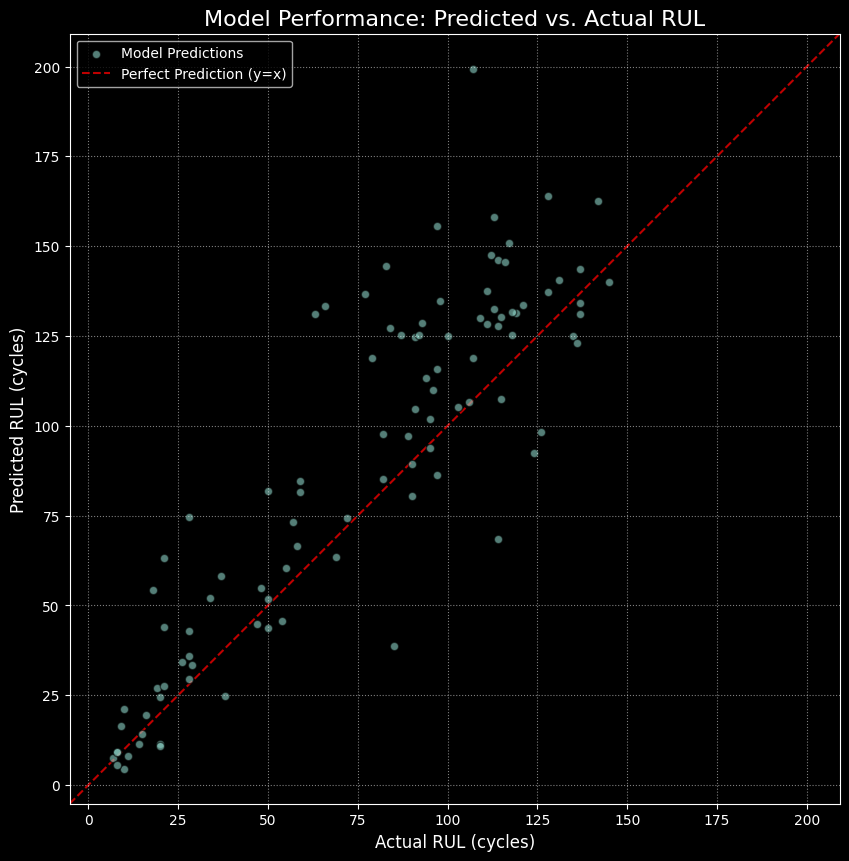

In [27]:
import matplotlib.pyplot as plt
import numpy as np

try:
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 10))

    ax.scatter(rul_true, rul_predictions, alpha=0.6, edgecolors='k', label='Model Predictions')

    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Prediction (y=x)')

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_title('Model Performance: Predicted vs. Actual RUL', fontsize=16)
    ax.set_xlabel('Actual RUL (cycles)', fontsize=12)
    ax.set_ylabel('Predicted RUL (cycles)', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.5)

    plt.show()

except NameError:
    print("Error: 'rul_true' or 'rul_predictions' not defined. Please run the previous cells first.")
except Exception as e:
    print(f"An error occurred during plotting: {e}")

In [28]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return np.sum(scores)

try:
    DATASET_TO_EVALUATE = 'FD001'

    rmse = np.sqrt(mean_squared_error(rul_true, rul_predictions))
    mae = mean_absolute_error(rul_true, rul_predictions)
    cmapss_score = calculate_cmapss_score(rul_true, rul_predictions)

    print(f"---  Regression Scores Report for {DATASET_TO_EVALUATE} ---")
    print(f"Mean Absolute Error (MAE):     {mae:.2f} cycles")
    print(f"Root Mean Squared Error (RMSE):  {rmse:.2f}")
    print(f"Asymmetric C-MAPSS Score:        {cmapss_score:.2f}")

except NameError:
    print("\nError: 'rul_true' or 'rul_predictions' is not defined. Please run the previous evaluation cells first.")

---  Regression Scores Report for FD001 ---
Mean Absolute Error (MAE):     19.01 cycles
Root Mean Squared Error (RMSE):  26.20
Asymmetric C-MAPSS Score:        14278.83


**Tuning for FD001**

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet

DATASET_TO_TRAIN = 'FD001'
WINDOW_SIZE = 40
MAX_RUL = 125
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 100
PATIENCE = 8
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72
VALIDATION_SPLIT = 0.2

def prepare_training_data(df_raw, window_size, max_rul):
    df_train = df_raw.copy()
    df_train['RUL'] = df_train.groupby('engine_id')['cycle'].transform(max) - df_train['cycle']
    df_train['RUL'] = np.clip(df_train['RUL'], 0, max_rul)
    feature_cols = [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
    static_cols = [col for col in feature_cols if df_train[col].std() == 0]
    feature_cols = [col for col in feature_cols if col not in static_cols]
    scaler = MinMaxScaler()
    df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
    sequences, labels = [], []
    for engine_id in df_train['engine_id'].unique():
        engine_df = df_train[df_train['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].values
        label_data = engine_df['RUL'].values
        for i in range(len(engine_df) - window_size + 1):
            sequences.append(feature_data[i:i+window_size])
            labels.append(label_data[i+window_size-1])
    return np.array(sequences), np.array(labels)

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

print(f"---  Starting Experiment for {DATASET_TO_TRAIN} ---")
print(f"Window Size: {WINDOW_SIZE}, LR: {LEARNING_RATE}, CNN Filters: {CNN_FILTERS}, LNN Units: {LNN_UNITS}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {DEVICE}")

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

data_path = 'data/'
file_path = os.path.join(data_path, f'train_{DATASET_TO_TRAIN}.txt')

try:
    df_raw = pd.read_csv(file_path, sep='\\s+', header=None, names=column_names)
    print(f"Successfully loaded {file_path}")

    X_train_np, y_train_np = prepare_training_data(df_raw, WINDOW_SIZE, MAX_RUL)
    X_tensor = torch.from_numpy(X_train_np).float()
    y_tensor = torch.from_numpy(y_train_np).float().view(-1, 1)
    dataset = TensorDataset(X_tensor, y_tensor)
    val_size = int(len(dataset) * VALIDATION_SPLIT)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    num_features = X_train_np.shape[2]
    model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        print(f"Epoch {epoch+1:03d}/{EPOCHS:03d} | Validation Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_tuned_model_{DATASET_TO_TRAIN}.pth')
            patience_counter = 0
            print("  -> Val loss improved. Saving model.")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("---  Early stopping triggered ---")
                break
    print("\n--- Training Finished ---")

except FileNotFoundError:
    print(f"Error: {file_path} not found. Please ensure it is in the '{data_path}' folder.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

---  Starting Experiment for FD001 ---
Window Size: 40, LR: 0.001, CNN Filters: 48, LNN Units: 150
Training on device: cpu
Successfully loaded data/train_FD001.txt


C:\Users\abhin\AppData\Local\Temp\ipykernel_14876\3618705131.py:25: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_train['RUL'] = df_train.groupby('engine_id')['cycle'].transform(max) - df_train['cycle']


Epoch 001/100 | Validation Loss: 2229.0697
  -> Val loss improved. Saving model.
Epoch 002/100 | Validation Loss: 531.9113
  -> Val loss improved. Saving model.
Epoch 003/100 | Validation Loss: 436.1815
  -> Val loss improved. Saving model.
Epoch 004/100 | Validation Loss: 394.5505
  -> Val loss improved. Saving model.
Epoch 005/100 | Validation Loss: 381.7724
  -> Val loss improved. Saving model.
Epoch 006/100 | Validation Loss: 365.8007
  -> Val loss improved. Saving model.
Epoch 007/100 | Validation Loss: 359.6363
  -> Val loss improved. Saving model.
Epoch 008/100 | Validation Loss: 384.6129
Epoch 009/100 | Validation Loss: 361.4266
Epoch 010/100 | Validation Loss: 363.4215
Epoch 011/100 | Validation Loss: 358.3448
  -> Val loss improved. Saving model.
Epoch 012/100 | Validation Loss: 359.4077
Epoch 013/100 | Validation Loss: 365.7232
Epoch 014/100 | Validation Loss: 367.3032
Epoch 015/100 | Validation Loss: 365.0745
Epoch 016/100 | Validation Loss: 350.5517
  -> Val loss improved.

KeyboardInterrupt: 

**Result for FD001**

In [36]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet
import os

# --- 1. Define Helper Functions / Classes / Constants ------------------------

# Re-defining constants from the training script
DATASET_TO_EVALUATE = 'FD001'
WINDOW_SIZE = 40
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

def calculate_cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return np.sum(scores)

# Re-defining the model class
class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

# --- 2. Main Evaluation Script ----------------------------------------------

try:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_path = 'data/'
    
    train_file = os.path.join(data_path, f'train_{DATASET_TO_EVALUATE}.txt')
    test_file = os.path.join(data_path, f'test_{DATASET_TO_EVALUATE}.txt')
    rul_file = os.path.join(data_path, f'RUL_{DATASET_TO_EVALUATE}.txt')
    model_file = f'best_tuned_model_{DATASET_TO_EVALUATE}.pth'

    print(f"---  Evaluating Model for {DATASET_TO_EVALUATE} ---")

    df_train_raw = pd.read_csv(train_file, sep='\\s+', header=None, names=column_names)
    df_test_raw = pd.read_csv(test_file, sep='\\s+', header=None, names=column_names)
    rul_true = np.loadtxt(rul_file)
    print("Loaded data files successfully.")

    static_cols = [col for col in df_train_raw.columns if df_train_raw[col].std() == 0]
    feature_cols = [col for col in df_train_raw.columns if col not in ['engine_id', 'cycle'] and col not in static_cols]
    num_features = len(feature_cols)
    
    scaler = MinMaxScaler()
    scaler.fit(df_train_raw[feature_cols])

    model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
    
    model.load_state_dict(torch.load(model_file))
    model.eval()
    print(f"Loaded model state from {model_file}")

    df_test_processed = df_test_raw.drop(columns=static_cols)
    df_test_processed[feature_cols] = scaler.transform(df_test_processed[feature_cols])

    sequences = []
    for engine_id in df_test_processed['engine_id'].unique():
        engine_df = df_test_processed[df_test_processed['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].tail(WINDOW_SIZE).values
        if feature_data.shape[0] < WINDOW_SIZE:
            padding = np.zeros((WINDOW_SIZE - feature_data.shape[0], num_features))
            feature_data = np.concatenate((padding, feature_data), axis=0)
        sequences.append(feature_data)
    X_test = torch.from_numpy(np.array(sequences)).float().to(DEVICE)

    with torch.no_grad():
        predictions = model(X_test).cpu().numpy().flatten()

    rmse = np.sqrt(mean_squared_error(rul_true, predictions))
    cmapss = calculate_cmapss_score(rul_true, predictions)

    print(f"\n---  Results for this Experiment ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"C-MAPSS Score: {cmapss:.2f}")

except FileNotFoundError as e:
    print(f"File not found. Make sure all files are in the 'data/' folder. Missing file: {e.filename}")
except Exception as e:
    print(f"An error occurred: {e}")

---  Evaluating Model for FD001 ---
Loaded data files successfully.
An error occurred: Error(s) in loading state_dict for HybridCnnLnn:
	Unexpected key(s) in state_dict: "lnn_core.sensory_mu", "lnn_core.sensory_sigma", "lnn_core.sensory_W", "lnn_core.sensory_erev", "lnn_core.mu", "lnn_core.sigma", "lnn_core.W", "lnn_core.erev", "lnn_core.vleak", "lnn_core.gleak", "lnn_core.cm_t". 


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet

# --- 1. Hyperparameter Configuration -----------------------------------------
DATASET_TO_TRAIN = 'FD002'
WINDOW_SIZE = 40
MAX_RUL = 125
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 100
PATIENCE = 8
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72
VALIDATION_SPLIT = 0.2

# --- 2. Reusable Functions (Data Prep and Model Definition) ------------------
def prepare_training_data(df_raw, window_size, max_rul):
    df_train = df_raw.copy()
    df_train['RUL'] = df_train.groupby('engine_id')['cycle'].transform(max) - df_train['cycle']
    df_train['RUL'] = np.clip(df_train['RUL'], 0, max_rul)
    feature_cols = [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
    static_cols = [col for col in feature_cols if df_train[col].std() == 0]
    feature_cols = [col for col in feature_cols if col not in static_cols]
    scaler = MinMaxScaler()
    df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
    sequences, labels = [], []
    for engine_id in df_train['engine_id'].unique():
        engine_df = df_train[df_train['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].values
        label_data = engine_df['RUL'].values
        for i in range(len(engine_df) - window_size + 1):
            sequences.append(feature_data[i:i+window_size])
            labels.append(label_data[i+window_size-1])
    return np.array(sequences), np.array(labels)

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

# --- 3. Main Experiment Script ----------------------------------------------
print(f"---  Starting Experiment for {DATASET_TO_TRAIN} ---")
print(f"Window Size: {WINDOW_SIZE}, LR: {LEARNING_RATE}, CNN Filters: {CNN_FILTERS}, LNN Units: {LNN_UNITS}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {DEVICE}")

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

data_path = 'data/'
file_path = os.path.join(data_path, f'train_{DATASET_TO_TRAIN}.txt')

try:
    df_raw = pd.read_csv(file_path, sep='\\s+', header=None, names=column_names)
    print(f"Successfully loaded {file_path}")

    X_train_np, y_train_np = prepare_training_data(df_raw, WINDOW_SIZE, MAX_RUL)
    X_tensor = torch.from_numpy(X_train_np).float()
    y_tensor = torch.from_numpy(y_train_np).float().view(-1, 1)
    dataset = TensorDataset(X_tensor, y_tensor)
    val_size = int(len(dataset) * VALIDATION_SPLIT)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    num_features = X_train_np.shape[2]
    model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        print(f"Epoch {epoch+1:03d}/{EPOCHS:03d} | Validation Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_tuned_model_{DATASET_TO_TRAIN}.pth')
            patience_counter = 0
            print("  -> Val loss improved. Saving model.")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("---  Early stopping triggered ---")
                break
    print("\n--- Training Finished ---")

except FileNotFoundError:
    print(f"Error: {file_path} not found. Please ensure it is in the '{data_path}' folder.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

---  Starting Experiment for FD002 ---
Window Size: 40, LR: 0.001, CNN Filters: 48, LNN Units: 150
Training on device: cpu
Successfully loaded data/train_FD002.txt


/var/folders/hp/0xysbm9s7v94tp381zp1_djm0000gn/T/ipykernel_8400/1965847069.py:27: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_train['RUL'] = df_train.groupby('engine_id')['cycle'].transform(max) - df_train['cycle']


Epoch 001/100 | Validation Loss: 2103.3913
  -> Val loss improved. Saving model.
Epoch 002/100 | Validation Loss: 952.2780
  -> Val loss improved. Saving model.
Epoch 003/100 | Validation Loss: 680.2891
  -> Val loss improved. Saving model.
Epoch 004/100 | Validation Loss: 675.4563
  -> Val loss improved. Saving model.
Epoch 005/100 | Validation Loss: 682.0170
Epoch 006/100 | Validation Loss: 521.8846
  -> Val loss improved. Saving model.
Epoch 007/100 | Validation Loss: 561.2427
Epoch 008/100 | Validation Loss: 487.8955
  -> Val loss improved. Saving model.
Epoch 009/100 | Validation Loss: 498.4381
Epoch 010/100 | Validation Loss: 479.9473
  -> Val loss improved. Saving model.
Epoch 011/100 | Validation Loss: 480.4541
Epoch 012/100 | Validation Loss: 545.7803
Epoch 013/100 | Validation Loss: 502.1275
Epoch 014/100 | Validation Loss: 508.0203
Epoch 015/100 | Validation Loss: 509.5301
Epoch 016/100 | Validation Loss: 486.3993
Epoch 017/100 | Validation Loss: 448.1512
  -> Val loss impro

In [38]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet
import os

DATASET_TO_EVALUATE = 'FD002'
WINDOW_SIZE = 40
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

def calculate_cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return np.sum(scores)

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

try:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_path = 'data/'
    
    train_file = os.path.join(data_path, f'train_{DATASET_TO_EVALUATE}.txt')
    test_file = os.path.join(data_path, f'test_{DATASET_TO_EVALUATE}.txt')
    rul_file = os.path.join(data_path, f'RUL_{DATASET_TO_EVALUATE}.txt')
    model_file = f'best_tuned_model_{DATASET_TO_EVALUATE}.pth'

    print(f"\n---  Evaluating Model for {DATASET_TO_EVALUATE} ---")

    df_train_raw = pd.read_csv(train_file, sep='\\s+', header=None, names=column_names)
    df_test_raw = pd.read_csv(test_file, sep='\\s+', header=None, names=column_names)
    rul_true = np.loadtxt(rul_file)
    print("Loaded data files successfully.")

    static_cols = [col for col in df_train_raw.columns if df_train_raw[col].std() == 0]
    feature_cols = [col for col in df_train_raw.columns if col not in ['engine_id', 'cycle'] and col not in static_cols]
    num_features = len(feature_cols)
    
    scaler = MinMaxScaler()
    scaler.fit(df_train_raw[feature_cols])

    model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
    
    model.load_state_dict(torch.load(model_file))
    model.eval()
    print(f"Loaded model state from {model_file}")

    df_test_processed = df_test_raw.drop(columns=static_cols)
    df_test_processed[feature_cols] = scaler.transform(df_test_processed[feature_cols])

    sequences = []
    for engine_id in df_test_processed['engine_id'].unique():
        engine_df = df_test_processed[df_test_processed['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].tail(WINDOW_SIZE).values
        if feature_data.shape[0] < WINDOW_SIZE:
            padding = np.zeros((WINDOW_SIZE - feature_data.shape[0], num_features))
            feature_data = np.concatenate((padding, feature_data), axis=0)
        sequences.append(feature_data)
    X_test = torch.from_numpy(np.array(sequences)).float().to(DEVICE)

    with torch.no_grad():
        predictions = model(X_test).cpu().numpy().flatten()

    rmse = np.sqrt(mean_squared_error(rul_true, predictions))
    cmapss = calculate_cmapss_score(rul_true, predictions)

    print(f"\n---  Scores for {DATASET_TO_EVALUATE} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"C-MAPSS Score: {cmapss:.2f}")

except FileNotFoundError as e:
    print(f"File not found. Make sure all files are in the 'data/' folder. Missing file: {e.filename}")
except Exception as e:
    print(f"An error occurred: {e}")


---  Evaluating Model for FD002 ---
Loaded data files successfully.
An error occurred: Error(s) in loading state_dict for HybridCnnLnn:
	Unexpected key(s) in state_dict: "lnn_core.sensory_mu", "lnn_core.sensory_sigma", "lnn_core.sensory_W", "lnn_core.sensory_erev", "lnn_core.mu", "lnn_core.sigma", "lnn_core.W", "lnn_core.erev", "lnn_core.vleak", "lnn_core.gleak", "lnn_core.cm_t". 


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet

DATASET_TO_TRAIN = 'FD003'
WINDOW_SIZE = 40
MAX_RUL = 125
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 6
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72
VALIDATION_SPLIT = 0.2

def prepare_training_data(df_raw, window_size, max_rul):
    df_train = df_raw.copy()
    df_train['RUL'] = df_train.groupby('engine_id')['cycle'].transform(max) - df_train['cycle']
    df_train['RUL'] = np.clip(df_train['RUL'], 0, max_rul)
    feature_cols = [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
    static_cols = [col for col in feature_cols if df_train[col].std() == 0]
    feature_cols = [col for col in feature_cols if col not in static_cols]
    scaler = MinMaxScaler()
    df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
    sequences, labels = [], []
    for engine_id in df_train['engine_id'].unique():
        engine_df = df_train[df_train['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].values
        label_data = engine_df['RUL'].values
        for i in range(len(engine_df) - window_size + 1):
            sequences.append(feature_data[i:i+window_size])
            labels.append(label_data[i+window_size-1])
    return np.array(sequences), np.array(labels)

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

print(f"---  Starting Experiment for {DATASET_TO_TRAIN} ---")
print(f"Window Size: {WINDOW_SIZE}, LR: {LEARNING_RATE}, CNN Filters: {CNN_FILTERS}, LNN Units: {LNN_UNITS}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {DEVICE}")

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

data_path = 'data/'
file_path = os.path.join(data_path, f'train_{DATASET_TO_TRAIN}.txt')

try:
    df_raw = pd.read_csv(file_path, sep='\\s+', header=None, names=column_names)
    print(f"Successfully loaded {file_path}")

    X_train_np, y_train_np = prepare_training_data(df_raw, WINDOW_SIZE, MAX_RUL)
    X_tensor = torch.from_numpy(X_train_np).float()
    y_tensor = torch.from_numpy(y_train_np).float().view(-1, 1)
    dataset = TensorDataset(X_tensor, y_tensor)
    val_size = int(len(dataset) * VALIDATION_SPLIT)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    num_features = X_train_np.shape[2]
    model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        print(f"Epoch {epoch+1:03d}/{EPOCHS:03d} | Validation Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_tuned_model_{DATASET_TO_TRAIN}.pth')
            patience_counter = 0
            print("  -> Val loss improved. Saving model.")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("---  Early stopping triggered ---")
                break
    print("\n--- Training Finished ---")

except FileNotFoundError:
    print(f"Error: {file_path} not found. Please ensure it is in the '{data_path}' folder.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

---  Starting Experiment for FD003 ---
Window Size: 40, LR: 0.001, CNN Filters: 48, LNN Units: 150
Training on device: cpu
Successfully loaded data/train_FD003.txt


/var/folders/hp/0xysbm9s7v94tp381zp1_djm0000gn/T/ipykernel_8400/815429152.py:25: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_train['RUL'] = df_train.groupby('engine_id')['cycle'].transform(max) - df_train['cycle']


Epoch 001/050 | Validation Loss: 1822.1932
  -> Val loss improved. Saving model.
Epoch 002/050 | Validation Loss: 1385.5106
  -> Val loss improved. Saving model.
Epoch 003/050 | Validation Loss: 324.9678
  -> Val loss improved. Saving model.
Epoch 004/050 | Validation Loss: 340.6286
Epoch 005/050 | Validation Loss: 328.6087
Epoch 006/050 | Validation Loss: 311.2808
  -> Val loss improved. Saving model.
Epoch 007/050 | Validation Loss: 312.6260
Epoch 008/050 | Validation Loss: 341.8049
Epoch 009/050 | Validation Loss: 340.1063
Epoch 010/050 | Validation Loss: 293.5366
  -> Val loss improved. Saving model.
Epoch 011/050 | Validation Loss: 294.3768
Epoch 012/050 | Validation Loss: 333.8050
Epoch 013/050 | Validation Loss: 290.1264
  -> Val loss improved. Saving model.
Epoch 014/050 | Validation Loss: 287.2562
  -> Val loss improved. Saving model.
Epoch 015/050 | Validation Loss: 282.5642
  -> Val loss improved. Saving model.
Epoch 016/050 | Validation Loss: 292.3950
Epoch 017/050 | Valida

In [40]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet
import os

DATASET_TO_EVALUATE = 'FD003'
WINDOW_SIZE = 40
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

def calculate_cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return np.sum(scores)

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

try:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_path = 'data/'
    
    train_file = os.path.join(data_path, f'train_{DATASET_TO_EVALUATE}.txt')
    test_file = os.path.join(data_path, f'test_{DATASET_TO_EVALUATE}.txt')
    rul_file = os.path.join(data_path, f'RUL_{DATASET_TO_EVALUATE}.txt')
    model_file = f'best_tuned_model_{DATASET_TO_EVALUATE}.pth'

    print(f"\n---  Evaluating Model for {DATASET_TO_EVALUATE} ---")

    df_train_raw = pd.read_csv(train_file, sep='\\s+', header=None, names=column_names)
    df_test_raw = pd.read_csv(test_file, sep='\\s+', header=None, names=column_names)
    rul_true = np.loadtxt(rul_file)
    print("Loaded data files successfully.")

    static_cols = [col for col in df_train_raw.columns if df_train_raw[col].std() == 0]
    feature_cols = [col for col in df_train_raw.columns if col not in ['engine_id', 'cycle'] and col not in static_cols]
    num_features = len(feature_cols)
    
    scaler = MinMaxScaler()
    scaler.fit(df_train_raw[feature_cols])

    model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
    
    model.load_state_dict(torch.load(model_file))
    model.eval()
    print(f"Loaded model state from {model_file}")

    df_test_processed = df_test_raw.drop(columns=static_cols)
    df_test_processed[feature_cols] = scaler.transform(df_test_processed[feature_cols])

    sequences = []
    for engine_id in df_test_processed['engine_id'].unique():
        engine_df = df_test_processed[df_test_processed['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].tail(WINDOW_SIZE).values
        if feature_data.shape[0] < WINDOW_SIZE:
            padding = np.zeros((WINDOW_SIZE - feature_data.shape[0], num_features))
            feature_data = np.concatenate((padding, feature_data), axis=0)
        sequences.append(feature_data)
    X_test = torch.from_numpy(np.array(sequences)).float().to(DEVICE)

    with torch.no_grad():
        predictions = model(X_test).cpu().numpy().flatten()

    rmse = np.sqrt(mean_squared_error(rul_true, predictions))
    cmapss = calculate_cmapss_score(rul_true, predictions)

    print(f"\n---  Scores for {DATASET_TO_EVALUATE} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"C-MAPSS Score: {cmapss:.2f}")

except FileNotFoundError as e:
    print(f"File not found. Make sure all files are in the 'data/' folder. Missing file: {e.filename}")
except Exception as e:
    print(f"An error occurred: {e}")


---  Evaluating Model for FD003 ---
Loaded data files successfully.
An error occurred: Error(s) in loading state_dict for HybridCnnLnn:
	Unexpected key(s) in state_dict: "lnn_core.sensory_mu", "lnn_core.sensory_sigma", "lnn_core.sensory_W", "lnn_core.sensory_erev", "lnn_core.mu", "lnn_core.sigma", "lnn_core.W", "lnn_core.erev", "lnn_core.vleak", "lnn_core.gleak", "lnn_core.cm_t". 


In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet

DATASET_TO_TRAIN = 'FD004'
WINDOW_SIZE = 40
MAX_RUL = 125
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 100
PATIENCE = 6
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72
VALIDATION_SPLIT = 0.2

def prepare_training_data(df_raw, window_size, max_rul):
    df_train = df_raw.copy()
    df_train['RUL'] = df_train.groupby('engine_id')['cycle'].transform(max) - df_train['cycle']
    df_train['RUL'] = np.clip(df_train['RUL'], 0, max_rul)
    feature_cols = [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
    static_cols = [col for col in feature_cols if df_train[col].std() == 0]
    feature_cols = [col for col in feature_cols if col not in static_cols]
    scaler = MinMaxScaler()
    df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
    sequences, labels = [], []
    for engine_id in df_train['engine_id'].unique():
        engine_df = df_train[df_train['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].values
        label_data = engine_df['RUL'].values
        for i in range(len(engine_df) - window_size + 1):
            sequences.append(feature_data[i:i+window_size])
            labels.append(label_data[i+window_size-1])
    return np.array(sequences), np.array(labels)

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

print(f"---  Starting Experiment for {DATASET_TO_TRAIN} ---")
print(f"Window Size: {WINDOW_SIZE}, LR: {LEARNING_RATE}, CNN Filters: {CNN_FILTERS}, LNN Units: {LNN_UNITS}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {DEVICE}")

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

data_path = 'data/'
file_path = os.path.join(data_path, f'train_{DATASET_TO_TRAIN}.txt')

try:
    df_raw = pd.read_csv(file_path, sep='\\s+', header=None, names=column_names)
    print(f"Successfully loaded {file_path}")

    X_train_np, y_train_np = prepare_training_data(df_raw, WINDOW_SIZE, MAX_RUL)
    X_tensor = torch.from_numpy(X_train_np).float()
    y_tensor = torch.from_numpy(y_train_np).float().view(-1, 1)
    dataset = TensorDataset(X_tensor, y_tensor)
    val_size = int(len(dataset) * VALIDATION_SPLIT)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    num_features = X_train_np.shape[2]
    model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        print(f"Epoch {epoch+1:03d}/{EPOCHS:03d} | Validation Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_tuned_model_{DATASET_TO_TRAIN}.pth')
            patience_counter = 0
            print("  -> Val loss improved. Saving model.")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("---  Early stopping triggered ---")
                break
    print("\n--- Training Finished ---")

except FileNotFoundError:
    print(f"Error: {file_path} not found. Please ensure it is in the '{data_path}' folder.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

---  Starting Experiment for FD004 ---
Window Size: 40, LR: 0.001, CNN Filters: 48, LNN Units: 150
Training on device: cpu
Successfully loaded data/train_FD004.txt


/var/folders/hp/0xysbm9s7v94tp381zp1_djm0000gn/T/ipykernel_8400/107950336.py:25: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_train['RUL'] = df_train.groupby('engine_id')['cycle'].transform(max) - df_train['cycle']


Epoch 001/100 | Validation Loss: 2070.9942
  -> Val loss improved. Saving model.
Epoch 002/100 | Validation Loss: 1131.3580
  -> Val loss improved. Saving model.
Epoch 003/100 | Validation Loss: 1099.4565
  -> Val loss improved. Saving model.
Epoch 004/100 | Validation Loss: 867.7177
  -> Val loss improved. Saving model.
Epoch 005/100 | Validation Loss: 677.5595
  -> Val loss improved. Saving model.
Epoch 006/100 | Validation Loss: 741.9064
Epoch 007/100 | Validation Loss: 578.2613
  -> Val loss improved. Saving model.
Epoch 008/100 | Validation Loss: 609.1689
Epoch 009/100 | Validation Loss: 534.6915
  -> Val loss improved. Saving model.
Epoch 010/100 | Validation Loss: 516.3570
  -> Val loss improved. Saving model.
Epoch 011/100 | Validation Loss: 601.4197
Epoch 012/100 | Validation Loss: 519.6743
Epoch 013/100 | Validation Loss: 508.0824
  -> Val loss improved. Saving model.
Epoch 014/100 | Validation Loss: 495.8049
  -> Val loss improved. Saving model.
Epoch 015/100 | Validation Lo

In [42]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet
import os

DATASET_TO_EVALUATE = 'FD004'
WINDOW_SIZE = 40
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

def calculate_cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return np.sum(scores)

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

try:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_path = 'data/'
    
    train_file = os.path.join(data_path, f'train_{DATASET_TO_EVALUATE}.txt')
    test_file = os.path.join(data_path, f'test_{DATASET_TO_EVALUATE}.txt')
    rul_file = os.path.join(data_path, f'RUL_{DATASET_TO_EVALUATE}.txt')
    model_file = f'best_tuned_model_{DATASET_TO_EVALUATE}.pth'

    print(f"\n---  Evaluating Model for {DATASET_TO_EVALUATE} ---")

    df_train_raw = pd.read_csv(train_file, sep='\\s+', header=None, names=column_names)
    df_test_raw = pd.read_csv(test_file, sep='\\s+', header=None, names=column_names)
    rul_true = np.loadtxt(rul_file)
    print("Loaded data files successfully.")

    static_cols = [col for col in df_train_raw.columns if df_train_raw[col].std() == 0]
    feature_cols = [col for col in df_train_raw.columns if col not in ['engine_id', 'cycle'] and col not in static_cols]
    num_features = len(feature_cols)
    
    scaler = MinMaxScaler()
    scaler.fit(df_train_raw[feature_cols])

    model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
    
    model.load_state_dict(torch.load(model_file))
    model.eval()
    print(f"Loaded model state from {model_file}")

    df_test_processed = df_test_raw.drop(columns=static_cols)
    df_test_processed[feature_cols] = scaler.transform(df_test_processed[feature_cols])

    sequences = []
    for engine_id in df_test_processed['engine_id'].unique():
        engine_df = df_test_processed[df_test_processed['engine_id'] == engine_id]
        feature_data = engine_df[feature_cols].tail(WINDOW_SIZE).values
        if feature_data.shape[0] < WINDOW_SIZE:
            padding = np.zeros((WINDOW_SIZE - feature_data.shape[0], num_features))
            feature_data = np.concatenate((padding, feature_data), axis=0)
        sequences.append(feature_data)
    X_test = torch.from_numpy(np.array(sequences)).float().to(DEVICE)

    with torch.no_grad():
        predictions = model(X_test).cpu().numpy().flatten()

    rmse = np.sqrt(mean_squared_error(rul_true, predictions))
    cmapss = calculate_cmapss_score(rul_true, predictions)

    print(f"\n---  Scores for {DATASET_TO_EVALUATE} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"C-MAPSS Score: {cmapss:.2f}")

except FileNotFoundError as e:
    print(f"File not found. Make sure all files are in the 'data/' folder. Missing file: {e.filename}")
except Exception as e:
    print(f"An error occurred: {e}")


---  Evaluating Model for FD004 ---
Loaded data files successfully.
An error occurred: Error(s) in loading state_dict for HybridCnnLnn:
	Unexpected key(s) in state_dict: "lnn_core.sensory_mu", "lnn_core.sensory_sigma", "lnn_core.sensory_W", "lnn_core.sensory_erev", "lnn_core.mu", "lnn_core.sigma", "lnn_core.W", "lnn_core.erev", "lnn_core.vleak", "lnn_core.gleak", "lnn_core.cm_t". 


In [43]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from liquidnet.main import LiquidNet
import os

WINDOW_SIZE = 40
CNN_FILTERS = 48
LNN_UNITS = 150
DENSE_UNITS = 72

column_names = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

def calculate_cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return np.sum(scores)

class HybridCnnLnn(nn.Module):
    def __init__(self, num_features, cnn_filters, lnn_units, dense_units):
        super(HybridCnnLnn, self).__init__()
        self.lnn_units = lnn_units
        self.cnn_feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=5, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters * 2, kernel_size=3, padding='same'),
            nn.ReLU(), nn.MaxPool1d(kernel_size=2), nn.Dropout(0.5))
        self.lnn_core = LiquidNet(num_units=lnn_units)
        self.output_head = nn.Sequential(
            nn.Linear(in_features=lnn_units, out_features=dense_units),
            nn.ReLU(), nn.Linear(in_features=dense_units, out_features=1))

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn_feature_extractor(x)
        x = x.permute(0, 2, 1)
        batch_size, seq_len = x.size(0), x.size(1)
        hidden_state = torch.zeros(batch_size, self.lnn_units).to(x.device)
        for t in range(seq_len):
            output, hidden_state = self.lnn_core(x[:, t, :], hidden_state)
        final_prediction = self.output_head(hidden_state)
        return final_prediction

try:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_path = 'data/'
    
    all_datasets = ['FD001', 'FD002', 'FD003', 'FD004']
    
    for DATASET_TO_EVALUATE in all_datasets:
        
        train_file = os.path.join(data_path, f'train_{DATASET_TO_EVALUATE}.txt')
        test_file = os.path.join(data_path, f'test_{DATASET_TO_EVALUATE}.txt')
        rul_file = os.path.join(data_path, f'RUL_{DATASET_TO_EVALUATE}.txt')
        model_file = f'best_tuned_model_{DATASET_TO_EVALUATE}.pth'

        print(f"\n---  Evaluating Model for {DATASET_TO_EVALUATE} ---")

        df_train_raw = pd.read_csv(train_file, sep='\\s+', header=None, names=column_names)
        df_test_raw = pd.read_csv(test_file, sep='\\s+', header=None, names=column_names)
        rul_true = np.loadtxt(rul_file)
        print("Loaded data files successfully.")

        static_cols = [col for col in df_train_raw.columns if df_train_raw[col].std() == 0]
        feature_cols = [col for col in df_train_raw.columns if col not in ['engine_id', 'cycle'] and col not in static_cols]
        num_features = len(feature_cols)
        
        scaler = MinMaxScaler()
        scaler.fit(df_train_raw[feature_cols])

        model = HybridCnnLnn(num_features, CNN_FILTERS, LNN_UNITS, DENSE_UNITS).to(DEVICE)
        
        print("Initializing model with a dummy pass...")
        dummy_input = torch.zeros(1, WINDOW_SIZE, num_features).to(DEVICE)
        model(dummy_input)
        
        model.load_state_dict(torch.load(model_file))
        model.eval()
        print(f"Loaded model state from {model_file}")

        df_test_processed = df_test_raw.drop(columns=static_cols)
        df_test_processed[feature_cols] = scaler.transform(df_test_processed[feature_cols])

        sequences = []
        for engine_id in df_test_processed['engine_id'].unique():
            engine_df = df_test_processed[df_test_processed['engine_id'] == engine_id]
            feature_data = engine_df[feature_cols].tail(WINDOW_SIZE).values
            if feature_data.shape[0] < WINDOW_SIZE:
                padding = np.zeros((WINDOW_SIZE - feature_data.shape[0], num_features))
                feature_data = np.concatenate((padding, feature_data), axis=0)
            sequences.append(feature_data)
        X_test = torch.from_numpy(np.array(sequences)).float().to(DEVICE)

        with torch.no_grad():
            predictions = model(X_test).cpu().numpy().flatten()

        rmse = np.sqrt(mean_squared_error(rul_true, predictions))
        cmapss = calculate_cmapss_score(rul_true, predictions)

        print(f"\n---  Scores for {DATASET_TO_EVALUATE} ---")
        print(f"RMSE: {rmse:.2f}")
        print(f"C-MAPSS Score: {cmapss:.2f}")

except FileNotFoundError as e:
    print(f"File not found. Make sure all files are in the 'data/' folder. Missing file: {e.filename}")
except Exception as e:
    print(f"An error occurred: {e}")


---  Evaluating Model for FD001 ---
Loaded data files successfully.
Initializing model with a dummy pass...
Loaded model state from best_tuned_model_FD001.pth

---  Scores for FD001 ---
RMSE: 18.39
C-MAPSS Score: 688.34

---  Evaluating Model for FD002 ---
Loaded data files successfully.
Initializing model with a dummy pass...
Loaded model state from best_tuned_model_FD002.pth

---  Scores for FD002 ---
RMSE: 32.67
C-MAPSS Score: 31271.38

---  Evaluating Model for FD003 ---
Loaded data files successfully.
Initializing model with a dummy pass...
Loaded model state from best_tuned_model_FD003.pth

---  Scores for FD003 ---
RMSE: 20.02
C-MAPSS Score: 1499.01

---  Evaluating Model for FD004 ---
Loaded data files successfully.
Initializing model with a dummy pass...
Loaded model state from best_tuned_model_FD004.pth

---  Scores for FD004 ---
RMSE: 35.31
C-MAPSS Score: 12725.92


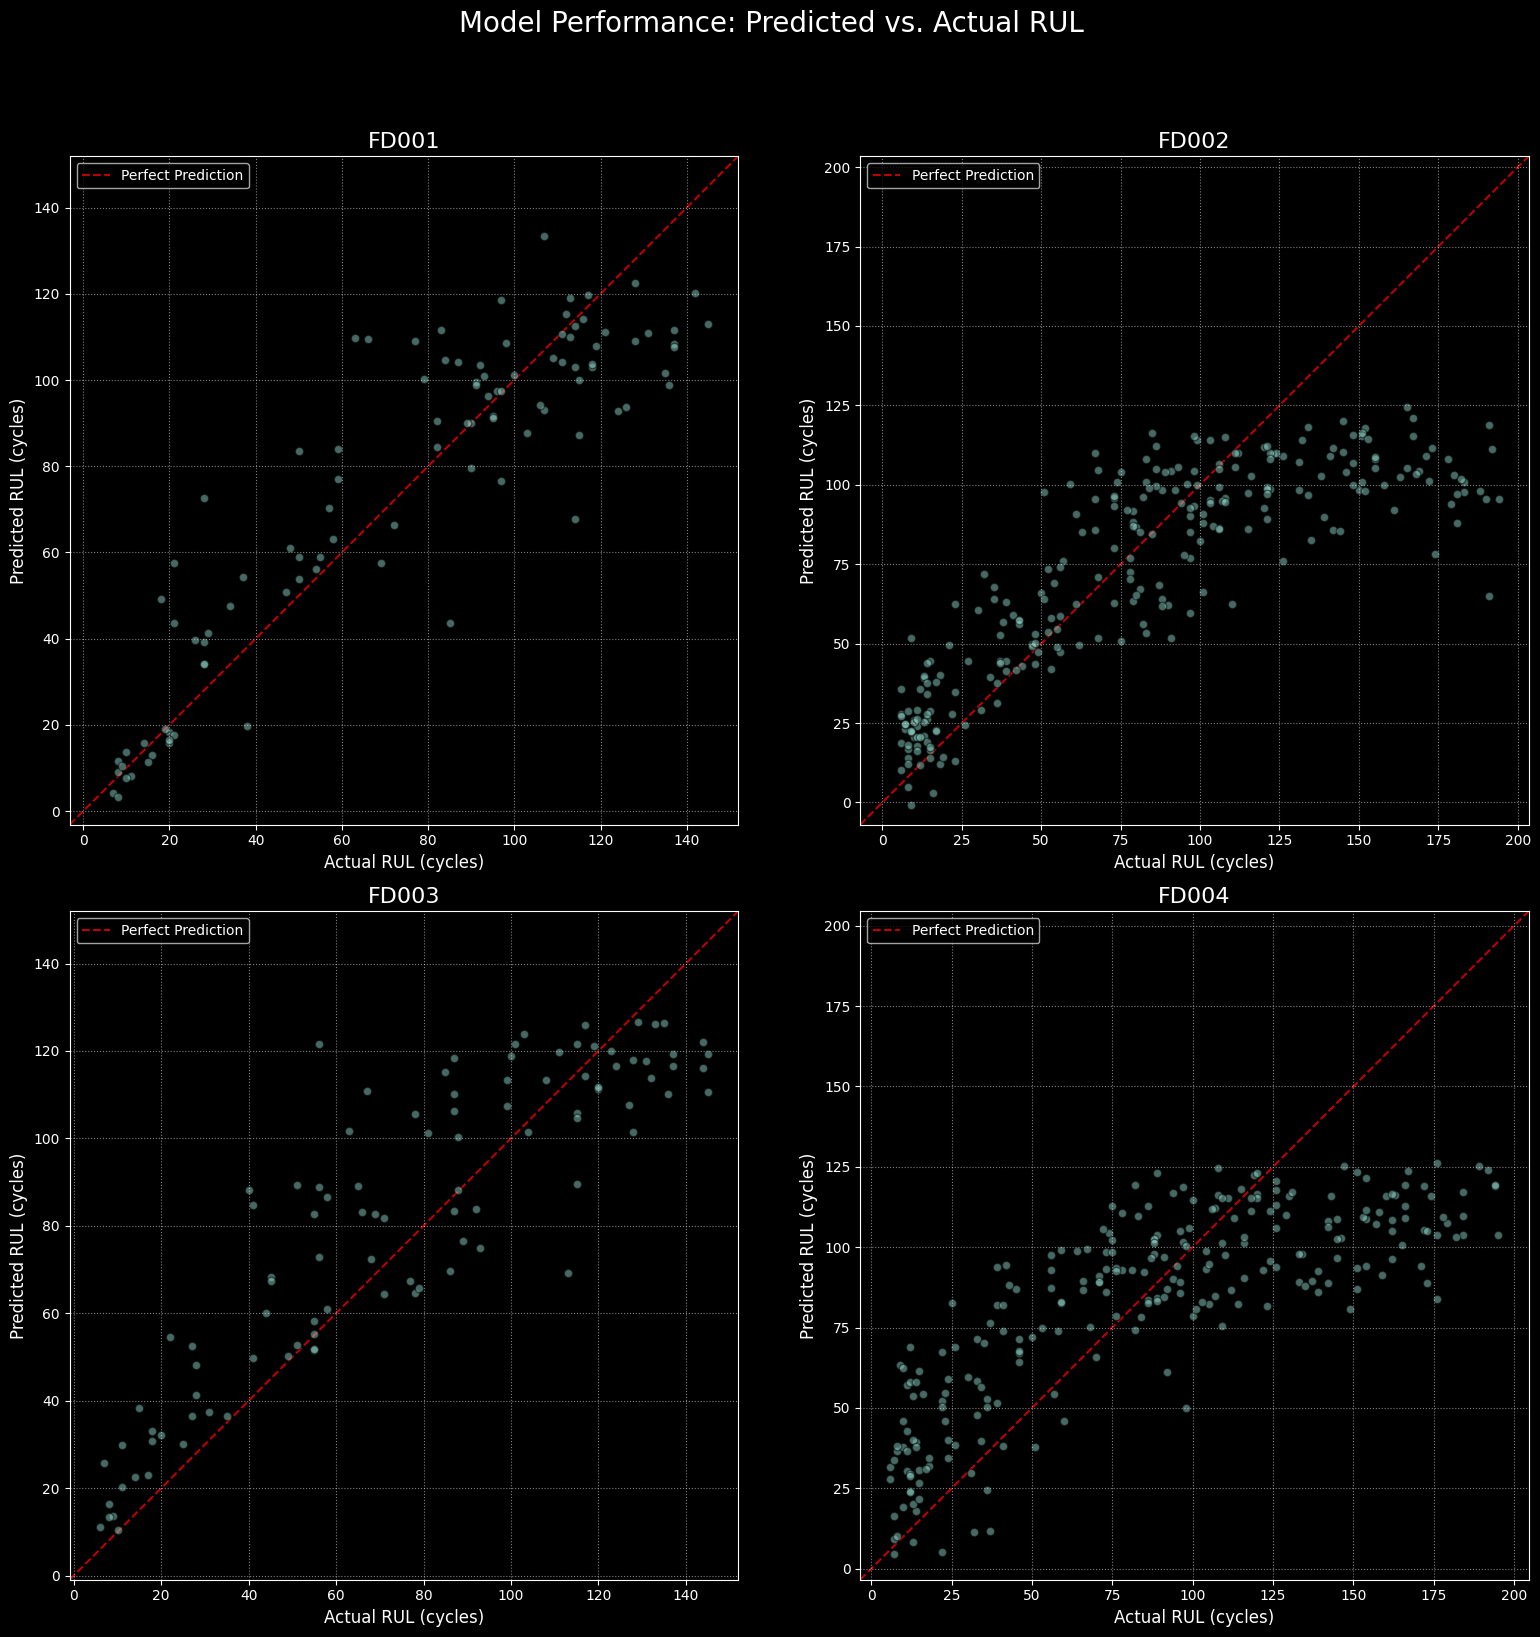

In [45]:
import matplotlib.pyplot as plt

try:
    if 'all_results' not in locals() or not all_results:
        print("Error: 'all_results' dictionary not found.")
        print("Please run the evaluation cell above this one first.")
    else:
        plt.style.use('dark_background')
        fig, axes = plt.subplots(2, 2, figsize=(16, 16))
        fig.suptitle('Model Performance: Predicted vs. Actual RUL', fontsize=20, y=1.02)
        
        axes_list = axes.flatten()
        
        for i, (dataset_name, data) in enumerate(all_results.items()):
            ax = axes_list[i]
            rul_true = data['rul_true']
            predictions = data['predictions']
            
            ax.scatter(rul_true, predictions, alpha=0.5, edgecolors='k')
            
            lims = [
                np.min([ax.get_xlim(), ax.get_ylim()]),
                np.max([ax.get_xlim(), ax.get_ylim()]),
            ]
            ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Prediction')
            
            ax.set_aspect('equal', adjustable='box')
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            
            ax.set_title(dataset_name, fontsize=16)
            ax.set_xlabel('Actual RUL (cycles)', fontsize=12)
            ax.set_ylabel('Predicted RUL (cycles)', fontsize=12)
            ax.legend()
            ax.grid(True, linestyle=':', alpha=0.5)

        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

except NameError as e:
    print(f"Error: A required variable is not defined: {e}")
except Exception as e:
    print(f"An error occurred during plotting: {e}")